In [ ]:
#Install required libraries
!pip install pandas numpy seaborn matplotlib scikit-learn imbalanced-learn joblib
#imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
#Load Titanic once
df = sns.load_dataset("titanic")

print("Dataset loaded successfully.")

sns.load_dataset("titanic")

pd.read_csv("titanic.csv")

Dataset loaded successfully.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
#Immediately save the raw dataset

df.to_csv("titanic.csv", index=False)

print("Offline fallback saved as titanic.csv")


Offline fallback saved as titanic.csv


In [ ]:

#Profile the dataset

print("===== INFO =====")
df.info()

print("\n===== DESCRIBE =====")
display(df.describe(include="all"))

print("\n===== SHAPE =====")
print(df.shape)


===== INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

===== DESCRIBE =====


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== SHAPE =====
(891, 15)


In [ ]:

#Profile the dataset

print("===== INFO =====")
df.info()

print("\n===== DESCRIBE =====")
display(df.describe(include="all"))

print("\n===== SHAPE =====")
print(df.shape)


===== INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

===== DESCRIBE =====


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== SHAPE =====
(891, 15)


In [ ]:
#Calculate missing percentages


missing = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage
})

missing_report = missing_report[
    missing_report["missing_count"] > 0
]

display(missing_report)



,missing_count,missing_percentage
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


In [ ]:
#Apply the required missing-value rule


df_clean = df.copy()

missing_pct = df_clean.isnull().mean() * 100

print("Missing-value percentages:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))


df_clean = df.copy()

missing_pct = df_clean.isnull().mean() * 100

print("Missing-value percentages:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))


Missing-value percentages:
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64
Missing-value percentages:
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


Remaining missing values:


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


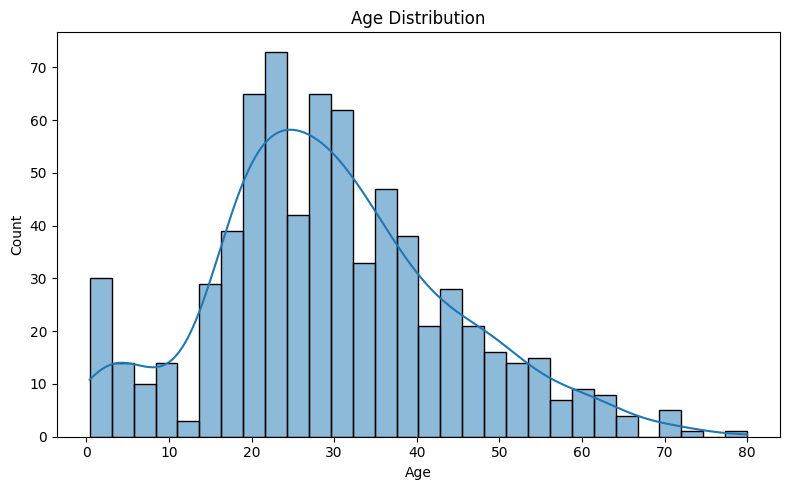

In [ ]:
#Verify cleaning

print("Remaining missing values:")
display(
    df_clean.isnull().sum()
)

#Age histogram

plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig("charts/age_histogram.png")
plt.show()

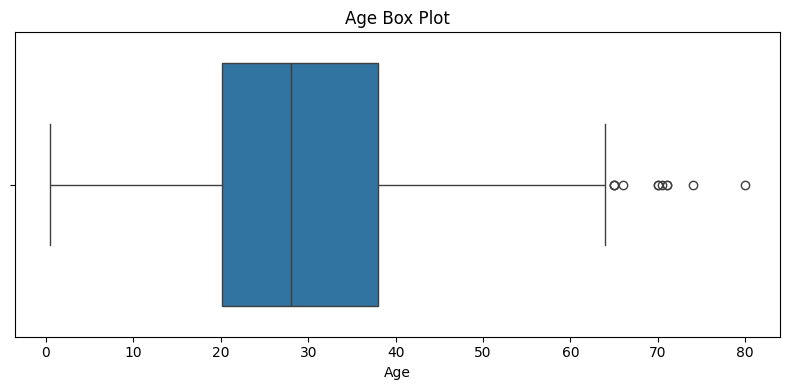

In [ ]:
#. Age box plot

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df_clean["age"]
)

plt.title("Age Box Plot")
plt.xlabel("Age")
plt.tight_layout()

plt.savefig("charts/age_boxplot.png")
plt.show()

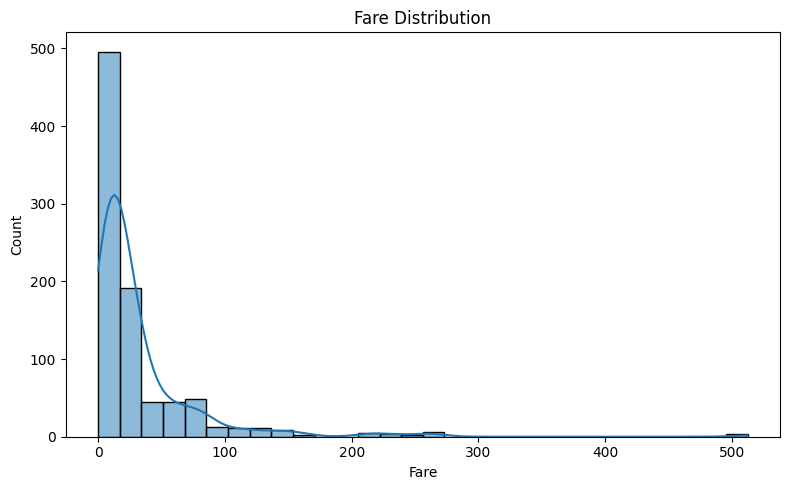

In [ ]:
#Fare histogram

plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["fare"],
    bins=30,
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig("charts/fare_histogram.png")
plt.show()

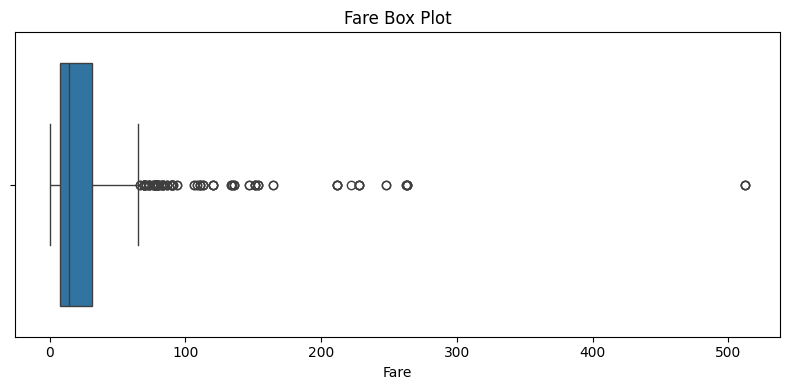

In [ ]:
#Fare box plot

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df_clean["fare"]
)

plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.tight_layout()

plt.savefig("charts/fare_boxplot.png")
plt.show()

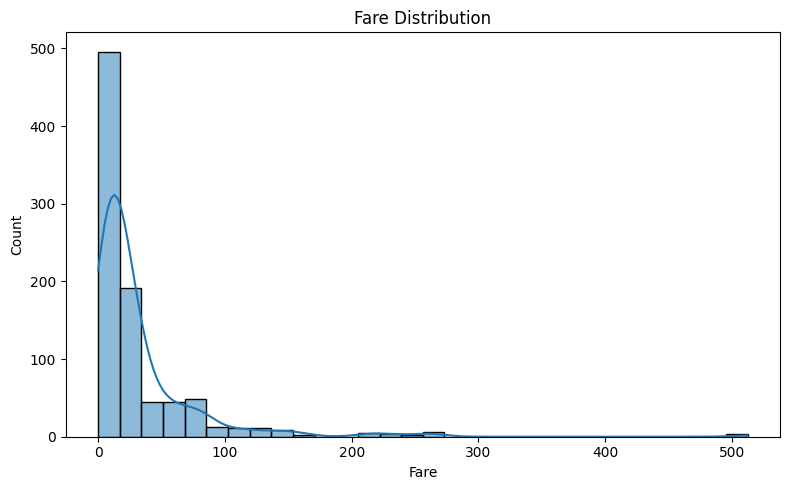

In [ ]:
#Fare histogram

plt.figure(figsize=(8, 5))

sns.histplot(
    df_clean["fare"],
    bins=30,
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig("charts/fare_histogram.png")
plt.show()

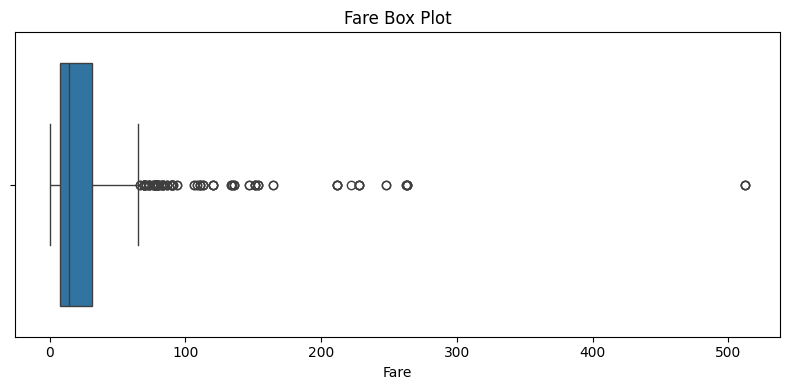

In [ ]:
#Fare box plot

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df_clean["fare"]
)

plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.tight_layout()

plt.savefig("charts/fare_boxplot.png")
plt.show()


AGE OUTLIERS
{'Q1': np.float64(20.125), 'Q3': np.float64(38.0), 'IQR': np.float64(17.875), 'lower_bound': np.float64(-6.6875), 'upper_bound': np.float64(64.8125), 'outlier_count': 11}

FARE OUTLIERS
{'Q1': np.float64(7.9104), 'Q3': np.float64(31.0), 'IQR': np.float64(23.0896), 'lower_bound': np.float64(-26.724), 'upper_bound': np.float64(65.6344), 'outlier_count': 116}
Fare Mean: 32.204207968574636
Fare Median: 14.4542
Fare Mode: 8.05
Female survival rate: 0.7420382165605095
Male survival rate: 0.18890814558058924
Female: 74.20%
Male: 18.89%
Class 1: 62.96%
Class 2: 47.28%
Class 3: 24.24%
male, Class 1: 36.89%
male, Class 2: 15.74%
male, Class 3: 13.54%
female, Class 1: 96.81%
female, Class 2: 92.11%
female, Class 3: 50.00%


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


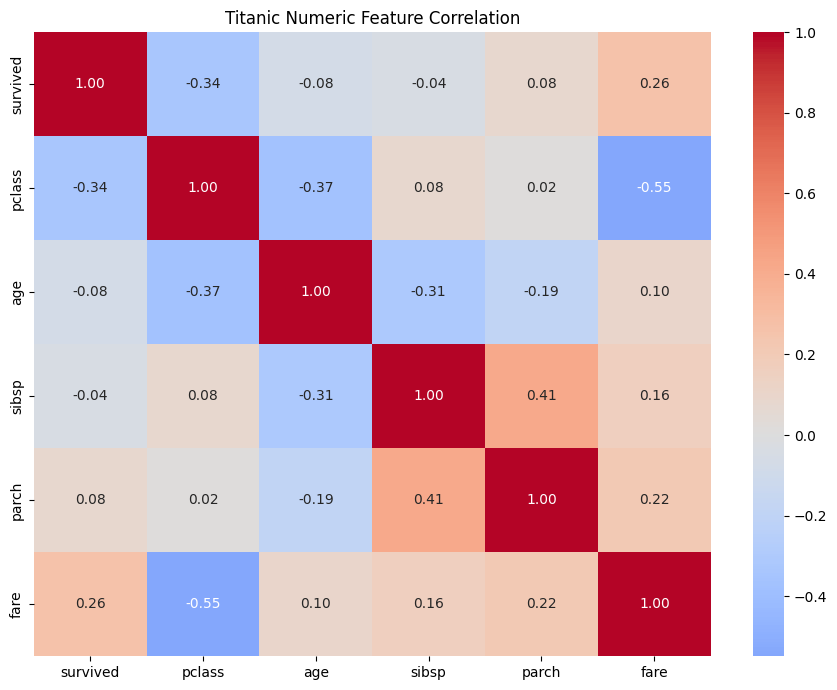

In [ ]:
import os

# Ensure the 'charts' directory exists
os.makedirs('charts', exist_ok=True)

#Calculate IQR outliers

def count_iqr_outliers(series):

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers)
    }


age_outliers = count_iqr_outliers(df_clean["age"])
fare_outliers = count_iqr_outliers(df_clean["fare"])

print("AGE OUTLIERS")
print(age_outliers)

print("\nFARE OUTLIERS")
print(fare_outliers)


#Fare mean, median and mode

fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)


#Survival by sex
female_survival = (
    df_clean[df_clean["sex"] == "female"]["survived"].mean()
)

male_survival = (
    df_clean[df_clean["sex"] == "male"]["survived"].mean()
)

print("Female survival rate:", female_survival)
print("Male survival rate:", male_survival)

print(
    f"Female: {female_survival * 100:.2f}%"
)

print(
    f"Male: {male_survival * 100:.2f}%"
)


#Survival by pclass

for pclass in sorted(df_clean["pclass"].unique()):

    rate = df_clean[
        df_clean["pclass"] == pclass
    ]["survived"].mean()

    print(
        f"Class {pclass}: {rate * 100:.2f}%"
    )


#Survival by sex AND class

for sex in df_clean["sex"].unique():

    for pclass in sorted(df_clean["pclass"].unique()):

        subset = df_clean[
            (df_clean["sex"] == sex) &
            (df_clean["pclass"] == pclass)
        ]

        rate = subset["survived"].mean()

        print(
            f"{sex}, Class {pclass}: "
            f"{rate * 100:.2f}%"
        )


#Correlation matrix — exactly six columns

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr = df_clean[
    correlation_columns
].corr()

display(corr)


#Correlation heatmap

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Titanic Numeric Feature Correlation")
plt.tight_layout()

plt.savefig("charts/correlation_heatmap.png")
plt.show()

In [ ]:
#Automatically find the two strongest correlations

corr_pairs = []

for i in range(len(corr.columns)):

    for j in range(i + 1, len(corr.columns)):

        feature_1 = corr.columns[i]
        feature_2 = corr.columns[j]
        coefficient = corr.iloc[i, j]

        corr_pairs.append({
            "feature_1": feature_1,
            "feature_2": feature_2,
            "correlation": coefficient,
            "absolute_correlation": abs(coefficient)
        })

corr_pairs_df = pd.DataFrame(corr_pairs)

strongest_two = (
    corr_pairs_df
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
    .head(2)
)

display(strongest_two)



,feature_1,feature_2,correlation,absolute_correlation
8,pclass,fare,-0.549500,0.549500
12,sibsp,parch,0.414838,0.414838


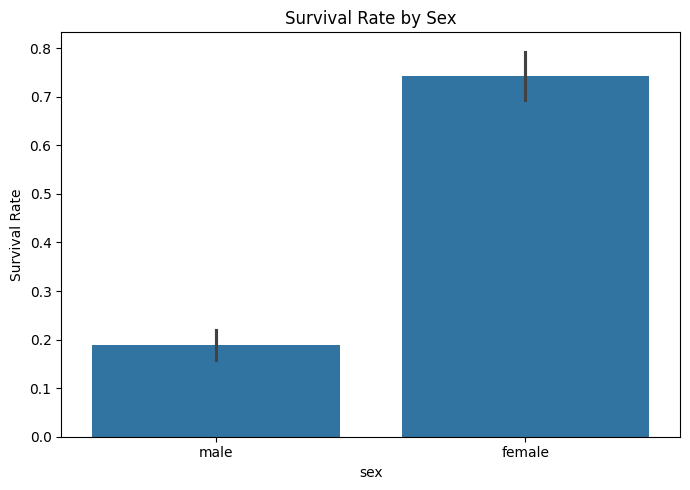

In [ ]:
#Multivariate data story — at least 4 charts

#Chart 1 - Survival by sex

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("charts/survival_by_sex.png")
plt.show()

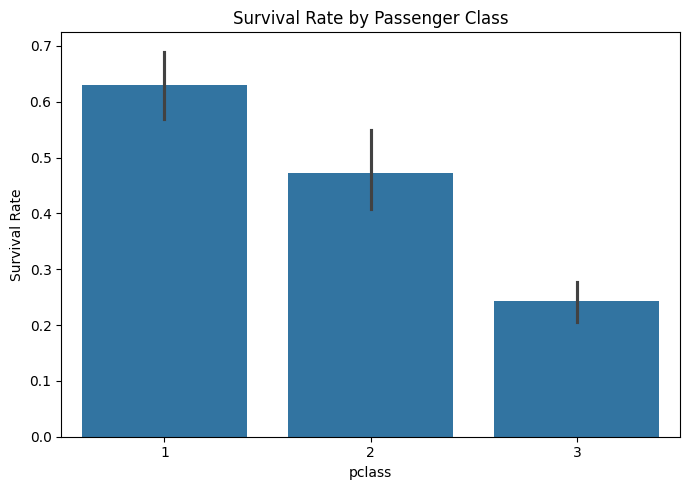

In [ ]:
import os

# Ensure the 'charts' directory exists
os.makedirs('charts', exist_ok=True)

#Chart 2 - Survival by passenger class

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("charts/survival_by_class.png")
plt.show()

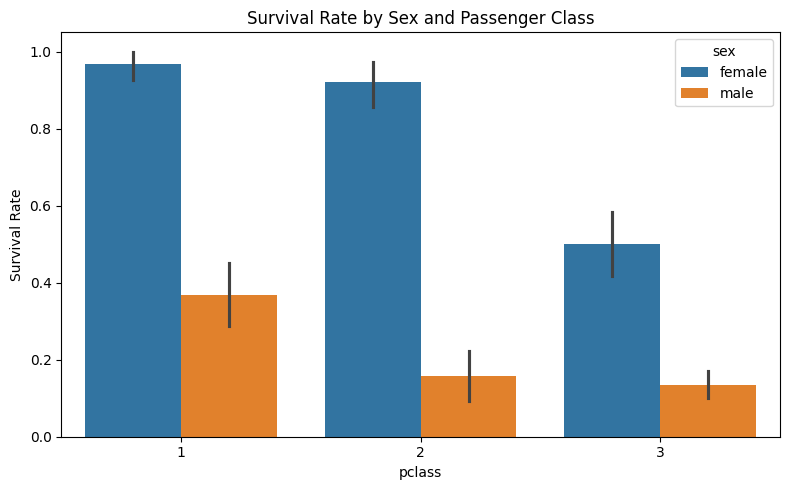

In [ ]:
# Chart 3 - Sex + passenger class

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.show()

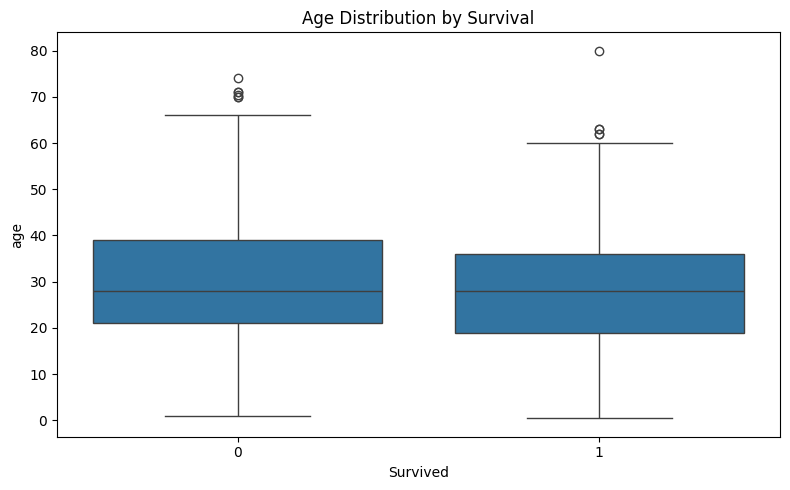

Before standardization:
            age       fare
mean  29.699118  32.204208
std   14.526497  49.693429

After standardization:
               age          fare
mean  2.388379e-16  3.987333e-18
std   1.000701e+00  1.000562e+00


In [ ]:
#Chart 4 - Age distribution by survival

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")

plt.tight_layout()
plt.show()

#EDA standardization check

scaler = StandardScaler()

df_eda_scaled = df_clean[
    ["age", "fare"]
].copy()

df_eda_scaled[
    ["age", "fare"]
] = scaler.fit_transform(
    df_eda_scaled[
        ["age", "fare"]
    ]
)

print("Before standardization:")
print(
    df_clean[["age", "fare"]]
    .agg(["mean", "std"])
)

print("\nAfter standardization:")
print(
    df_eda_scaled[["age", "fare"]]
    .agg(["mean", "std"])
)
